# Deteksi Kebaruan dan Anomali (Novelty and Outlier Detection)

Catatan ini menguraikan metodologi untuk mendeteksi data yang menyimpang dari distribusi normal (*anomalies*). Berbeda dengan klasifikasi standar yang mempelajari batas antar-kelas, algoritma deteksi anomali pada umumnya merupakan algoritma *Unsupervised Learning* atau *Semi-Supervised Learning* yang berfokus pada identifikasi titik observasi yang tidak wajar.

Fokus utama pada modul ini adalah memahami perbedaan konseptual antara Deteksi Kebaruan (*Novelty Detection*) dan Deteksi Anomali (*Outlier Detection*), serta implementasi algoritma fundamental seperti *Isolation Forest*, *Local Outlier Factor* (LOF), dan *One-Class SVM*.

#### **Tujuan Pembelajaran**
* Membedakan paradigma *Outlier Detection* (beroperasi pada himpunan data yang sudah tercemar anomali) dan *Novelty Detection* (mendeteksi anomali pada data baru berdasarkan data latih yang bersih).
* Memahami dan mengimplementasikan algoritma berbasis pohon *Isolation Forest* untuk memisahkan anomali secara efisien.
* Memahami dan mengimplementasikan algoritma berbasis kepadatan *Local Outlier Factor* (LOF) untuk menemukan anomali lokal.
* Mengaplikasikan *One-Class SVM* untuk mengisolasi himpunan data normal menggunakan metode kernel.

In [48]:
# Memuat pustaka komputasi numerik dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat pembuat dataset sintetis
from sklearn.datasets import make_blobs

# Memuat modul algoritma Deteksi Anomali
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Konfigurasi parameter dasar dan visualisasi
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Pustaka untuk Deteksi Anomali dan Kebaruan berhasil dimuat.")

Pustaka untuk Deteksi Anomali dan Kebaruan berhasil dimuat.


## 1. Outlier Detection vs Novelty Detection

Dalam ekosistem `scikit-learn`, entitas yang dianggap tidak normal (anomali) direpresentasikan dengan nilai prediksi `-1`, sedangkan entitas normal (*inliers*) direpresentasikan dengan nilai `1`.

* **Outlier Detection:** Mengasumsikan bahwa himpunan data latih yang kita miliki sudah terkontaminasi oleh anomali. Algoritma berusaha mencocokkan region dengan kepadatan data tinggi dan mengabaikan titik-titik yang terisolasi.
* **Novelty Detection:** Mengasumsikan bahwa data latih sepenuhnya bersih dari anomali. Algoritma menyusun batas absolut di sekitar data latih untuk mendeteksi apakah observasi baru (*test data*) termasuk ke dalam distribusi normal atau dianggap sebagai hal baru yang menyimpang (*novelty*).

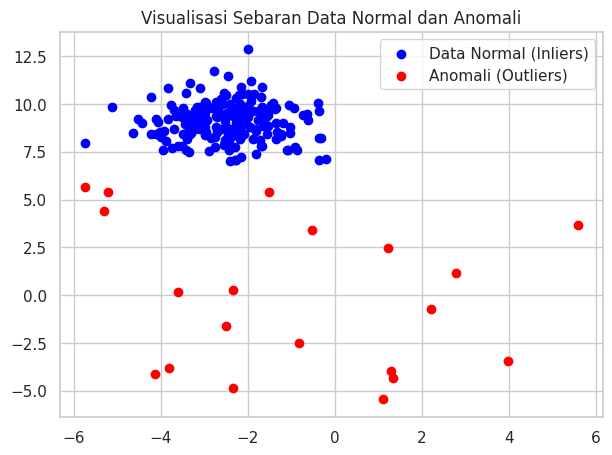

In [49]:
# 1. Membuat data normal (Inliers)
X_normal, _ = make_blobs(n_samples=200, centers=1, cluster_std=1.0, random_state=42)

# 2. Menghasilkan anomali acak (Outliers)
rng = np.random.RandomState(42)
X_outliers = rng.uniform(low=-6, high=6, size=(20, 2))

# 3. Menggabungkan dataset (Simulasi data yang terkontaminasi)
X_terkontaminasi = np.vstack([X_normal, X_outliers])

# Visualisasi Data Mentah
plt.figure(figsize=(7, 5))
plt.scatter(X_normal[:, 0], X_normal[:, 1], c='blue', label='Data Normal (Inliers)')
plt.scatter(X_outliers[:, 0], X_outliers[:, 1], c='red', label='Anomali (Outliers)')
plt.title("Visualisasi Sebaran Data Normal dan Anomali")
plt.legend()
plt.show()

## 2. Isolation Forest

*Isolation Forest* beroperasi berdasarkan prinsip pemisahan menggunakan *Decision Trees* acak. Asumsi mendasarnya adalah bahwa data anomali (*outliers*) berjumlah sedikit dan memiliki karakteristik fitur yang jauh berbeda.

Oleh karena itu, jika kita melakukan pemisahan acak, data anomali akan sangat cepat "terisolasi" ke dalam simpul daun tersendiri (membutuhkan jalur pemisahan yang sangat pendek). Algoritma ini memiliki efisiensi komputasi yang luar biasa dan sangat direkomendasikan untuk himpunan data berdimensi tinggi.

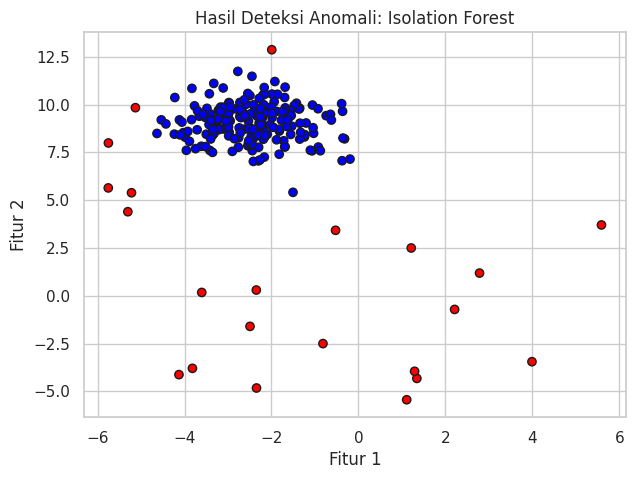

Total anomali terdeteksi: 22 titik dari total 220 data.


In [50]:
# Inisialisasi Isolation Forest
# Parameter 'contamination' mengatur estimasi persentase anomali dalam dataset
iso_forest = IsolationForest(contamination=0.1, random_state=42)

# Melatih model dan memprediksi label anomali
prediksi_if = iso_forest.fit_predict(X_terkontaminasi)

# Plot hasil deteksi
plt.figure(figsize=(7, 5))
warna_prediksi = np.where(prediksi_if == 1, 'blue', 'red')
plt.scatter(X_terkontaminasi[:, 0], X_terkontaminasi[:, 1], c=warna_prediksi, edgecolor='k')
plt.title("Hasil Deteksi Anomali: Isolation Forest")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

print(f"Total anomali terdeteksi: {np.sum(prediksi_if == -1)} titik dari total {len(X_terkontaminasi)} data.")

## 3. Local Outlier Factor (LOF)

LOF adalah algoritma berbasis kepadatan (*density-based*). Algoritma ini membandingkan kepadatan lokal dari sebuah titik observasi terhadap kepadatan lokal tetangga-tetangganya.

Jika sebuah titik memiliki tingkat kepadatan yang jauh lebih rendah dibandingkan dengan tetangganya, titik tersebut diidentifikasi sebagai anomali lokal. LOF sangat superior untuk menemukan anomali pada dataset yang memiliki beberapa klaster dengan tingkat kepadatan yang sangat bervariasi.

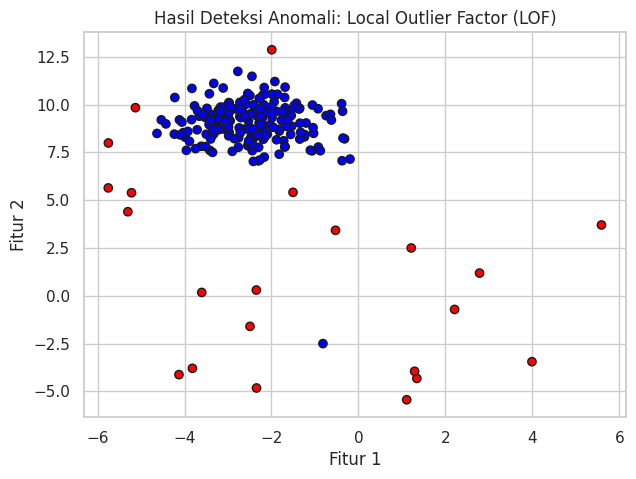

In [51]:
# Inisialisasi Local Outlier Factor
# n_neighbors mendefinisikan jumlah tetangga untuk kalkulasi kepadatan lokal
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

# Fit dan Prediksi secara bersamaan (karena LOF konvensional adalah algoritma Unsupervised tanpa tahap inferensi data baru)
prediksi_lof = lof.fit_predict(X_terkontaminasi)

# Plot hasil deteksi
plt.figure(figsize=(7, 5))
warna_lof = np.where(prediksi_lof == 1, 'blue', 'red')
plt.scatter(X_terkontaminasi[:, 0], X_terkontaminasi[:, 1], c=warna_lof, edgecolor='k')
plt.title("Hasil Deteksi Anomali: Local Outlier Factor (LOF)")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

## 4. One-Class SVM

*One-Class SVM* adalah algoritma perluasan dari *Support Vector Machines* yang secara khusus didesain untuk **Deteksi Kebaruan (Novelty Detection)**.

Algoritma ini beroperasi dengan memproyeksikan himpunan data latih yang bersih (tanpa anomali) ke ruang berdimensi tinggi menggunakan fungsi kernel (misalnya RBF). Model kemudian mencari *hyperplane* sempit yang melingkupi distribusi data normal secara maksimal. Segala bentuk observasi baru yang mendarat di luar garis batas (*margin*) tersebut secara otomatis akan divonis sebagai anomali.

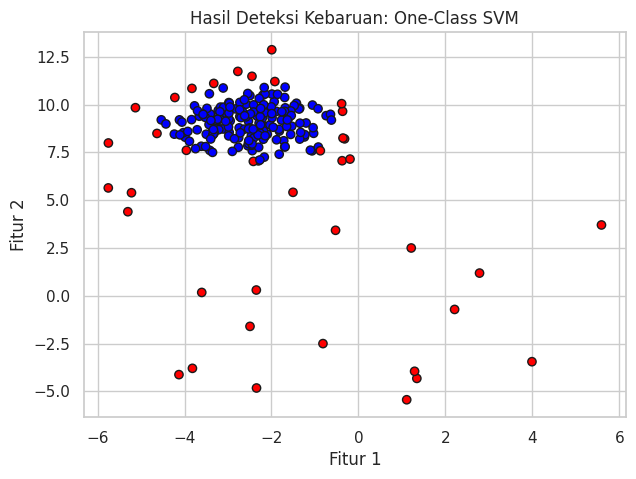

In [52]:
# Inisialisasi One-Class SVM
# Parameter 'nu' merepresentasikan batas atas proporsi margin error (estimasi kontaminasi)
ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)

# Perhatian: One-Class SVM sebaiknya HANYA dilatih pada data normal (Inliers)
ocsvm.fit(X_normal)

# Memprediksi keseluruhan data (Inliers + Outliers)
prediksi_ocsvm = ocsvm.predict(X_terkontaminasi)

# Plot hasil deteksi
plt.figure(figsize=(7, 5))
warna_ocsvm = np.where(prediksi_ocsvm == 1, 'blue', 'red')
plt.scatter(X_terkontaminasi[:, 0], X_terkontaminasi[:, 1], c=warna_ocsvm, edgecolor='k')
plt.title("Hasil Deteksi Kebaruan: One-Class SVM")
plt.xlabel("Fitur 1")
plt.ylabel("Fitur 2")
plt.show()

## Kesimpulan

Penanganan observasi abnormal merupakan krusialitas dalam memastikan kualitas data operasional dan keamanan sistem (misal: sistem pendeteksi intrusi atau penipuan perbankan).

**Panduan Pemilihan Algoritma:**
1. Gunakan **Isolation Forest** sebagai standar utama (*baseline*) untuk deteksi anomali (*Outlier Detection*) secara umum, terutama apabila berhadapan dengan dataset berskala besar dan dimensi fitur tinggi.
2. Gunakan **Local Outlier Factor (LOF)** apabila dataset Anda dicurigai memiliki banyak kelompok klaster namun dengan tingkat kepadatan yang sangat tidak stabil antar-klasternya.
3. Gunakan **One-Class SVM** secara eksklusif untuk **Novelty Detection**, yakni ketika Anda sudah mengamankan himpunan data latih yang terverifikasi bersih 100% dan Anda ingin memfilter segala bentuk entitas asing di masa mendatang. Skala fitur (*Feature Scaling*) mutlak diperlukan pada algoritma ini.